# Analyzing attack experiment

## What is this 'notebook'?
This is a Jupyter Notebook. It is a tool that allows us to write and execute code in an interactive way. We can also add text, images, and other media to explain what we are doing. This makes it a great tool for data analysis and visualization. In this notebook, we will use Python to analyze the finger-tapping data that we collected during the experiment.

---

In this environment, you can run the code cells by clicking on them and pressing Shift + Enter. You can also edit the code and run it again to see how it works. Don't worry about making mistakes, that's part of the learning process! You can always go back to the original code by clicking File > Revert Notebook to Checkpoint.

---

Enjoy! Don't worry about understanding everything (especially not the code of course). If you're interested, and if you have any questions, feel free to ask!

## First step: Loading the libraries that we will use

In [1]:
# Install packages
%pip install pandas numpy matplotlib seaborn statsmodels

# Importing 'packages'
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Define constants
TRIAL_CONDITIONS = [50, 150, 0, 100, 200]
STIMULUS_INTERVAL = 0.5
N_INTERVALS = 24
STIMULUS_ONSETS = np.cumsum([0] + [STIMULUS_INTERVAL] * N_INTERVALS)[:-1]


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Data pre-processing

The data that comes out of the experiment is in a raw format (and a bit of a mess). We need to process it to make it usable for analysis. This involves several steps, such as cleaning the data, extracting relevant features, and organizing it in a way that we can easily analyze.

---

Below we first load the data from the experiment, and then save them in a more usable format (CSV files). We will also do some basic cleaning and feature extraction to prepare the data for analysis. Note that first we start with the **onsets** data (and then later we will do the inter-onset intervals, or IOIs). We also save the onsets of the stimulus.

*Please don't worry about the code below; it's a bit technical, but it's just a way to automate the data processing. The important thing is that we end up with clean and organized data that we can analyze later on.*

In [10]:
onsets = pd.DataFrame()

filenames = [file for file in os.listdir('./data') if file.endswith('.csv')]

# We loop over all files, then over all trials, and then we extract the stimulus onsets and response onsets; we check for responses that happened before the stimulus started or after the stimulus ended (all stimuli were 15 seconds long) and remove those; we also check the difference between stimulus and response; note that there may be missing responses, so we remove the stimulus onset from the tap that is the closest
for file in filenames:
    df_response = pd.read_csv(os.path.join('./data', file))
    pp_id = df_response.participant[0]
    for trial, trial_df in df_response.groupby('fileName'):
        stimulus_t_zero = trial_df["stimulus.started"].dropna().values[0]
        resp_onsets_t = trial_df["resp.time"].dropna().values
        resp_onsets = resp_onsets_t - stimulus_t_zero
        # get indices of resp onsets that are smaller than 0 (these are taps that happened before the stimulus started or after the stimulus ended (all stimuli were 15 seconds long)
        resp_onsets_wrong_indices = np.where((resp_onsets < 0) | (resp_onsets > 15))[0]
        resp_onsets = np.delete(resp_onsets, resp_onsets_wrong_indices)
        resp_velocity = trial_df["resp.velocity"].dropna().values
        resp_velocity = np.delete(resp_velocity, resp_onsets_wrong_indices)
        # For each tap, find the stimulus onset that is closest to it; this will be the stimulus that the participant was tapping to; we also check the difference between stimulus and response; note that there may be missing responses, so we remove the stimulus onset from the tap that is the closest
        closest_stim_onsets = [STIMULUS_ONSETS[np.argmin(np.abs(resp_onset - STIMULUS_ONSETS))] for resp_onset in resp_onsets]
        tap_location = np.array(resp_onsets) - np.array(closest_stim_onsets)

        for stim_resp in ['stimulus', 'response']:
            onsets = pd.concat([onsets, pd.DataFrame({
                'pp_id': pp_id,
                'trial_condition': trial.split('_')[-1].strip('ms.wav'),
                'stimulus_response': stim_resp,
                'onset_i': np.arange(len(resp_onsets)) + 1 if stim_resp == 'response' else np.arange(len(STIMULUS_ONSETS)) + 1,
                'onset': resp_onsets if stim_resp == 'response' else STIMULUS_ONSETS,
                'tap_location': tap_location if stim_resp == 'response' else np.nan,
                'velocity': resp_velocity if stim_resp == 'response' else np.nan
            })]).reset_index(drop=True)

onsets.to_csv(os.path.join(".", "data", "processed", "onsets.csv"), index=False)

If want to take a quick look at the data, we can use the `head()` function to see the first few rows of the dataframes. This can give us a sense of what the data looks like and what kind of information it contains. We can also use the `info()` function to get a summary of the data, including the number of rows, columns, and data types. This can help us identify any issues with the data, such as missing values or incorrect data types.

In [11]:
onsets.head(30)

,pp_id,trial_condition,stimulus_response,onset_i,onset,tap_location,velocity
0,jelle2,0,stimulus,1,0.000000,NaN,NaN
1,jelle2,0,stimulus,2,0.500000,NaN,NaN
2,jelle2,0,stimulus,3,1.000000,NaN,NaN
3,jelle2,0,stimulus,4,1.500000,NaN,NaN
4,jelle2,0,stimulus,5,2.000000,NaN,NaN
5,jelle2,0,stimulus,6,2.500000,NaN,NaN
6,jelle2,0,stimulus,7,3.000000,NaN,NaN
7,jelle2,0,stimulus,8,3.500000,NaN,NaN
8,jelle2,0,stimulus,9,4.000000,NaN,NaN
9,jelle2,0,stimulus,10,4.500000,NaN,NaN


--- 

Maybe here take a pause: What do you think all the columns mean?

---

Another quick way to take a look at the data is to use the `describe()` function, which gives us summary statistics for the numerical columns in the dataframe. This can help us understand the distribution of the data and identify any outliers or unusual values.

In [12]:
onsets.describe()

,onset_i,onset,tap_location,velocity
count,564.000000,564.000000,276.000000,276.000000
mean,12.260638,5.949715,0.027678,63.297101
std,6.801772,3.428748,0.145932,21.033621
min,1.000000,0.000000,-0.249884,17.000000
25%,6.000000,3.000000,-0.026207,47.000000
50%,12.000000,6.000000,0.033970,59.000000
75%,18.000000,9.000000,0.120790,80.000000
max,24.000000,12.001940,0.501940,118.000000


## Inter-onset intervals

We also make a new dataframe to for the inter-onset intervals (IOIs). We calculate the IOIs by taking the difference between consecutive onsets.

In [15]:
iois = pd.DataFrame()

for pp_id, pp_df in onsets[onsets['stimulus_response'] == 'response'].groupby('pp_id'):
    for trial_condition, trial_df in pp_df.groupby('trial_condition'):
        trial_onsets = trial_df[trial_df['stimulus_response'] == stim_resp]['onset'].values
        iois_trial = np.diff(trial_onsets)
        iois = pd.concat([iois, pd.DataFrame({
            'pp_id': pp_id,
            'trial_condition': trial_condition,
            'ioi_i': np.arange(len(iois_trial)) + 1,
            'ioi': iois_trial
        })]).reset_index(drop=True)

Again, we can can take a quick look at the IOI data using the `head()` and `describe()` functions to get a sense of what the data looks like and to check for any issues.
Now you can type the ``iois.head()`` and ``iois.describe()`` commands to take a look at the IOI data, use the empty cell below:

## Plotting the data

The first step to any data analysis is to visualize the data. This can help us understand the data better and identify any patterns or trends. We can use various plotting libraries in Python, such as Matplotlib and Seaborn, to create different types of plots. Remember that now we have two *dataframes*: one for the onsets and one for the IOIs. We can plot both of them to see how they look.

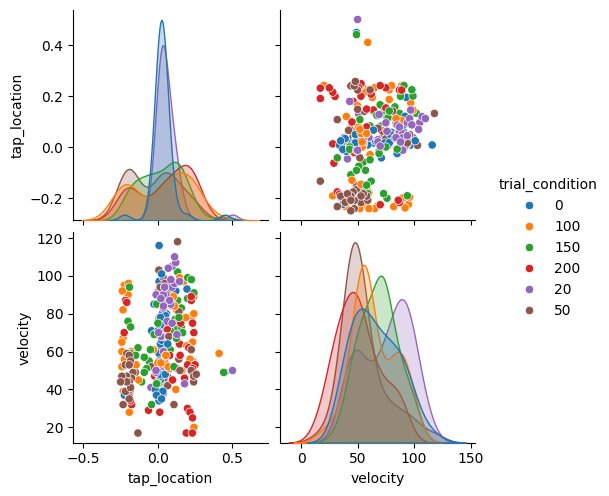

In [18]:
# plot the timing of the onset (relative to the stimulus) and the velocity of the response, colored by trial condition
p = sns.pairplot(onsets, hue="trial_condition", vars=["tap_location", "velocity"])

### Tap location by trial condition (i.e. amount of attack)
Does the location of the tap (i.e. which finger) change with the amount of attack? The onset values as recorded here are relative to the onset of the sound.
So, if a person taps for instance 20 milliseconds after the sound starts, the onset value will be 20. If they tap before the sound starts, the onset value will be negative (e.g. -10 if they tap 10 milliseconds before the sound starts). We can plot the onsets for each trial condition (i.e. each level of attack) to see if there are any differences in tap location.

To do so, we use 'probability density plots' (or KDE plots) to visualize the distribution of tap locations for each trial condition. Probability density plots
are basically smoothed out histograms that show the distribution of a continuous variable (in this case, the onsets). If the resulting plot shows that the distribution of onsets is different for different trial conditions, this could suggest that the amount of attack affects the tap location. For example, if we see that the distribution of onsets is more spread out for higher levels of attack, this could indicate that participants are tapping more variably in response to stronger attacks (this is what they called 'beat bin' in Danielsen et al., 2024). On the other hand, if the distribution of onsets is similar across trial conditions, this could suggest that the amount of attack does not affect the tap location.

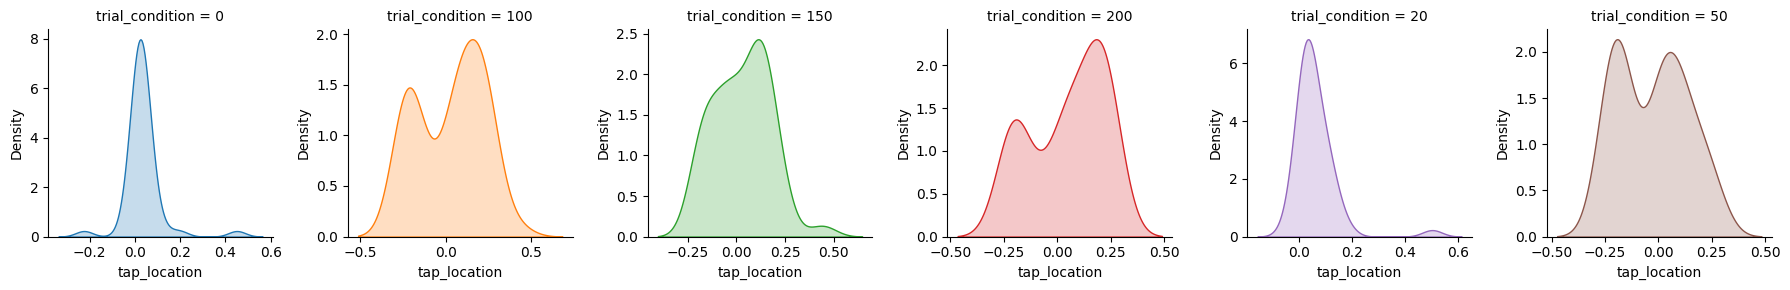

In [19]:
# First we select only the data from the database that is the "response"
onsets_response = onsets[onsets.stimulus_response == "response"]

# We create a grid onto which to plot
g = sns.FacetGrid(onsets_response, col="trial_condition", hue="trial_condition", sharex=False, sharey=False)

# Then we plot the 'probability density', here called kde, of the onsets for each trial condition (i.e. each level of attack)
g.map(sns.kdeplot, "tap_location", fill=True)

What do you see in this plot? Are there differences in the distribution of onsets across trial conditions? Do you see any patterns or trends in the data? 

### Tapping variability by position in the sequence
Generally, when people tap along with a sequence of sounds, their tapping tends to be more variable at the beginning of the sequence and becomes more stable as they get into the groove. This is because it takes some time for people to synchronize their tapping with the sounds, and once they are in sync, their tapping becomes more consistent. We can plot the variability of tapping by using boxplots. The wider the box, the more variable the tapping is. If we see that the boxes are wider at the beginning of the sequence and become narrower towards the end, this would suggest that tapping variability decreases as people get into the groove.

/Users/jellevanderwerff/.pyenv/versions/3.11.13/lib/python3.11/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


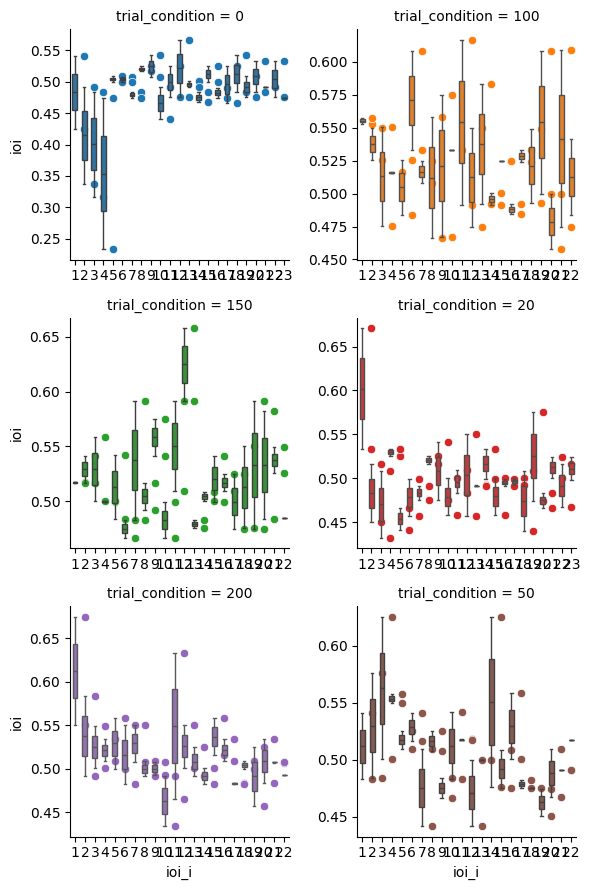

In [22]:
# Create a grid for plotting
g = sns.FacetGrid(iois, col="trial_condition", hue="trial_condition", col_wrap=2, sharex=False, sharey=False)
# Plot scatters and boxplots of IOIs for each trial condition
g.map(sns.scatterplot, "ioi_i", "ioi")
g.map(sns.boxplot, "ioi_i", "ioi", showfliers=False, width=0.5)

What do you see here? Do you see a decrease in tapping variability as the sequence progresses? Are there any differences in this pattern across trial conditions (i.e. different levels of attack)? As a hint, the amount of variability is given by the spread of the points in the scatterplot, and by the size of the boxes in the boxplot. If you see that the points are more spread out and the boxes are larger at the beginning of the sequence, this could indicate that tapping is more variable at the beginning. If you see that the points become less spread out and the boxes become smaller as the sequence progresses, this could indicate that tapping becomes more stable as people get into the groove.